<a href="https://colab.research.google.com/github/ABamukhayyar/AI_stock_Market_Prediction/blob/AI-models/testing_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Regression

## Importing the libraries

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [57]:
dataset = pd.read_csv('TASI_Historical_Data.csv')


In [58]:
# Convert 'Date' to datetime just in case
dataset['Date'] = pd.to_datetime(dataset['Date'], format='mixed', dayfirst=False)

# Sort from Oldest to Newest
dataset = dataset.sort_values('Date', ascending=True).reset_index(drop=True)
# Reset the index so the numbers start from 0 again
dataset = dataset.reset_index(drop=True)
# C. Remove '%' from Change columnA
# Check if column is string before fixing (in case pandas already read it as float)
if dataset['Change %'].dtype == object:
    dataset['Change %'] = dataset['Change %'].str.replace('%', '').astype(float)

# D. Remove Commas ',' from Price columns
cols_to_fix = ['Price', 'Open', 'High', 'Low']
for col in cols_to_fix:
    if dataset[col].dtype == object: # Only if it's currently a string
        dataset[col] = dataset[col].str.replace(',', '').astype(float)
# Clean Volume (Crucial Step!)
def clean_volume(x):
    if isinstance(x, str):
        x = x.upper().replace(',', '')
        if 'M' in x: return float(x.replace('M', '')) * 1_000_000
        if 'B' in x: return float(x.replace('B', '')) * 1_000_000_000
        if 'K' in x: return float(x.replace('K', '')) * 1_000
    return float(x)

dataset['Vol.'] = dataset['Vol.'].apply(clean_volume).fillna(0)

# 1. CREATE THE NEW TARGET
# "shift(-1)" moves all prices UP by one day.
# So Row 0 (Jan 1) now contains the Price of Jan 2.
dataset['Next_Day_Price'] = dataset['Price'].shift(-1)
# 2. DROP THE LAST ROW
# The very last day of your data (e.g., 2026) has no "Tomorrow",
# so 'Next_Day_Price' will be NaN (Empty). We must remove it.
dataset = dataset.dropna()

print("Data Cleaned Successfully!")
print(dataset.head())
print(dataset['Date'].dtype)
# ... (Previous cleaning code for Date, Commas, Volume) ...

print("Checking for NaNs before fixing...")
print(dataset.isnull().sum()) # This will show you which columns have blanks

# --- THE FIX: DROP ROWS WHERE PRICE IS MISSING ---
dataset = dataset.dropna(subset=['Price'])

# Optional: Double check that X columns don't have NaNs either
# If you used fillna(0) on Volume earlier, you should be safe.
# But just in case, let's drop rows where ANY feature is missing to be safe
dataset = dataset.dropna()

print("Rows remaining after dropping NaNs:", len(dataset))

# 1. SMA_20 (20-Day Simple Moving Average)
# Helps the model see the "Trend"
dataset['SMA_20'] = dataset['Price'].rolling(window=20).mean()

# 2. RSI (Relative Strength Index)
# Helps the model see "Overbought/Oversold"
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

dataset['RSI'] = calculate_rsi(dataset['Price'])

# 3. Clean up NaNs created by the indicators
# (First 20 days will be empty because they don't have enough history)
dataset = dataset.dropna()

print("Indicators Added: SMA_20 and RSI")
print(dataset[['Date', 'Price', 'SMA_20', 'RSI']].head())


Data Cleaned Successfully!
        Date     Open     High      Low        Vol.  Change %    Price  \
0 2008-09-22  7538.65  7544.06  7425.66  38030000.0     -1.03  7461.14   
1 2008-09-24  7461.14  7461.14  6961.01  72180000.0     -4.39  7133.47   
2 2008-09-27  7133.47  7133.47  6885.52  59510000.0     -1.97  6993.13   
3 2008-09-28  6993.13  7489.98  6992.72  91540000.0      6.65  7458.50   
4 2008-10-06  7458.50  7458.50  6724.09  42080000.0     -9.81  6726.60   

   Next_Day_Price  
0         7133.47  
1         6993.13  
2         7458.50  
3         6726.60  
4         6253.72  
datetime64[ns]
Checking for NaNs before fixing...
Date              0
Open              0
High              0
Low               0
Vol.              0
Change %          0
Price             0
Next_Day_Price    0
dtype: int64
Rows remaining after dropping NaNs: 3998
Indicators Added: SMA_20 and RSI
         Date    Price     SMA_20        RSI
19 2008-10-27  5338.68  6400.7385  36.257524
20 2008-10-28  5621.9

In [59]:
X = dataset.drop(['Date', 'Next_Day_Price'], axis=1).values
y = dataset['Next_Day_Price'].values

## Training the Random Forest Regression model on the whole dataset

In [74]:
from sklearn.model_selection import train_test_split
train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Training on first {train_size} days")
print(f"Testing on last {len(y_test)} days")

Training on first 3581 days
Testing on last 398 days


In [75]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

## Predicting a new result

In [76]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[10787.51 10701.79]
 [10721.32 10558.58]
 [10628.13 10555.71]
 [10567.69 10469.5 ]
 [10534.28 10507.72]
 [10523.39 10412.16]
 [10385.67 10419.44]
 [10343.01 10519.74]
 [10475.75 10496.59]
 [10541.2  10573.05]
 [10570.33 10548.45]
 [10602.84 10493.17]
 [10538.21 10370.97]
 [10343.53 10269.73]
 [10239.78 10153.3 ]
 [10207.57 10051.78]
 [10103.75  9994.79]
 [10008.21 10102.7 ]
 [10142.05 10192.26]
 [10181.4  10277.76]
 [10269.73 10411.26]
 [10391.86 10447.96]
 [10461.94 10473.32]
 [10519.67 10410.21]
 [10372.49 10463.18]
 [10485.82 10383.82]
 [10361.84 10305.09]
 [10323.45 10207.17]
 [10246.13 10048.5 ]
 [10060.72  9976.65]
 [10013.07 10157.73]
 [10131.68 10218.12]
 [10170.37 10359.74]
 [10386.55 10350.51]
 [10364.89 10446.39]
 [10431.75 10459.36]
 [10484.38 10463.61]
 [10519.91 10468.08]
 [10496.55 10503.18]
 [10534.65 10590.1 ]
 [10584.3  10636.62]
 [10674.07 10806.89]
 [10781.74 10948.6 ]
 [10972.28 10920.63]
 [10909.17 10906.15]
 [10878.12 10965.78]
 [11004.83 10905.48]
 [10898.15 10

## Visualising the Random Forest Regression results (higher resolution)

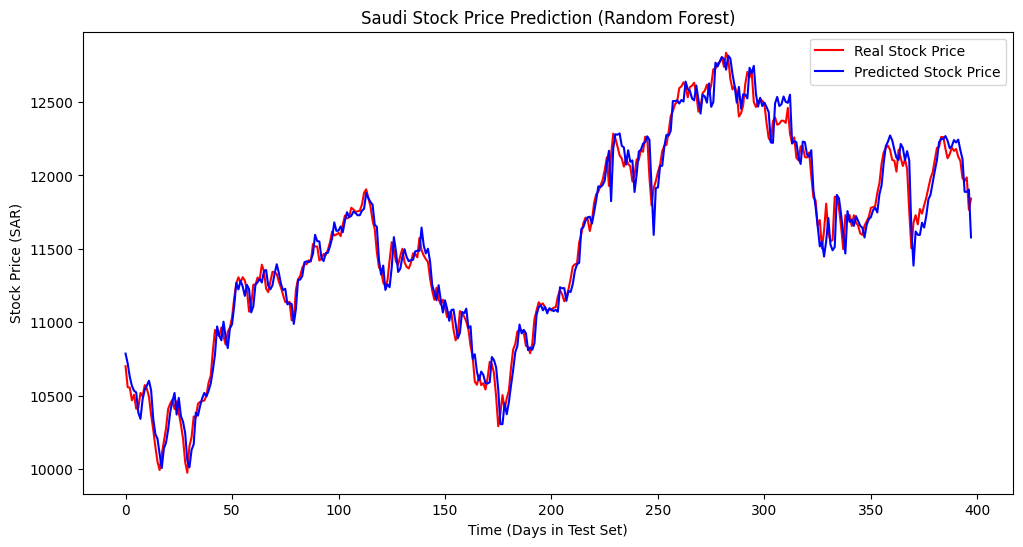


Predicted vs Real:
[[10787.51 10701.79]
 [10721.32 10558.58]
 [10628.13 10555.71]
 [10567.69 10469.5 ]
 [10534.28 10507.72]
 [10523.39 10412.16]
 [10385.67 10419.44]
 [10343.01 10519.74]
 [10475.75 10496.59]
 [10541.2  10573.05]]


In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6)) # Make it big enough to read

# Plot Real Prices (Red)
plt.plot(y_test, color='red', label='Real Stock Price')

# Plot Predicted Prices (Blue)
plt.plot(y_pred, color='blue', label='Predicted Stock Price')

plt.title('Saudi Stock Price Prediction (Random Forest)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (SAR)')
plt.legend() # Show the label box
plt.show()

print("\nPredicted vs Real:")
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1)[:10])

In [69]:
from sklearn.metrics import r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Accuracy Score (R2): {r2:.4f}")

Root Mean Squared Error (RMSE): 97.63
Accuracy Score (R2): 0.9791
